# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)

## Load Dataset

In [2]:
df = pd.read_csv("clean_data.csv")

df.head()

,age,country_region,device_type,education_background,course_level,course_category,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,32.0,3,0,2,2,0,12.0,1.0,7.6,1.0,6.0,1.0,1.0,53.3,0.655,0.0,49.8
1,17.0,3,0,2,2,4,34.0,16.0,27.2,6.0,4.0,7.0,1.0,51.5,1.000,1.0,84.0
2,25.0,3,1,0,0,4,39.0,6.0,7.1,16.0,2.0,2.0,0.0,62.2,0.810,0.0,62.5
3,26.0,2,1,2,1,2,10.0,34.0,22.1,57.0,9.0,6.0,0.0,59.3,0.875,1.0,89.5
4,26.0,2,2,3,0,0,12.0,22.0,32.3,41.0,9.0,2.0,0.0,65.1,0.814,0.0,67.4


# CLASSIFICATION

## Features & Target

In [3]:
X = df.drop(["completion_status"],axis=1)
y = df["completion_status"]

## Train Test Split

In [4]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

## Decision Tree Classifier

In [5]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)
dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:,1]

## Decision Tree Evaluation

In [6]:
dt_accuracy = accuracy_score(y_test,dt_pred)
dt_precision = precision_score(y_test,dt_pred)
dt_recall = recall_score(y_test,dt_pred)
dt_f1 = f1_score(y_test,dt_pred)
dt_auc = roc_auc_score(y_test,dt_prob)

print("Decision Tree")
print("Accuracy :",dt_accuracy)
print("Precision :",dt_precision)
print("Recall :",dt_recall)
print("F1 :",dt_f1)
print("ROC AUC :",dt_auc)

Decision Tree
Accuracy : 0.7682692307692308
Precision : 0.6792452830188679
Recall : 0.732824427480916
F1 : 0.7050183598531212
ROC AUC : 0.7613117500619417


## Gradient Boosting Classifier

In [ ]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train,y_train)
gb_pred = gb.predict(X_test)
gb_prob = gb.predict_proba(X_test)[:,1]

## Evaluation

In [8]:
gb_accuracy = accuracy_score(y_test,gb_pred)
gb_precision = precision_score(y_test,gb_pred)
gb_recall = recall_score(y_test,gb_pred)
gb_f1 = f1_score(y_test,gb_pred)
gb_auc = roc_auc_score(y_test,gb_prob)

print("Gradient Boosting")
print("Accuracy :",gb_accuracy)
print("Precision :",gb_precision)
print("Recall :",gb_recall)
print("F1 :",gb_f1)
print("ROC AUC :",gb_auc)

Gradient Boosting
Accuracy : 0.8336538461538462
Precision : 0.7879581151832461
Recall : 0.7659033078880407
F1 : 0.7767741935483871
ROC AUC : 0.903760161402598


## Confusion Matrix

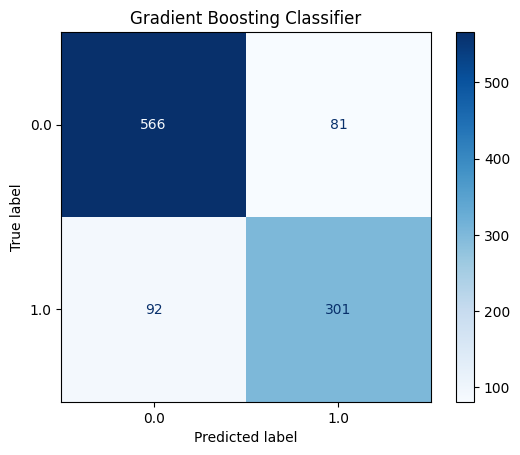

In [9]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    gb_pred,
    cmap="Blues"
)

plt.title("Gradient Boosting Classifier")
plt.show()

## ROC Curve

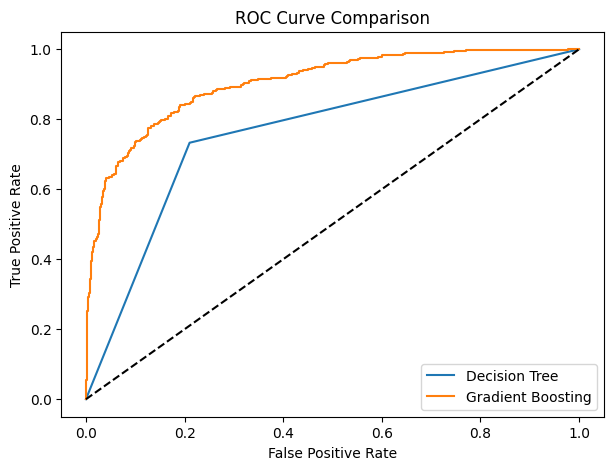

In [10]:
dt_fpr,dt_tpr,_ = roc_curve(y_test,dt_prob)
gb_fpr,gb_tpr,_ = roc_curve(y_test,gb_prob)

plt.figure(figsize=(7,5))

plt.plot(dt_fpr,dt_tpr,label="Decision Tree")
plt.plot(gb_fpr,gb_tpr,label="Gradient Boosting")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

## Learning Rate Analysis

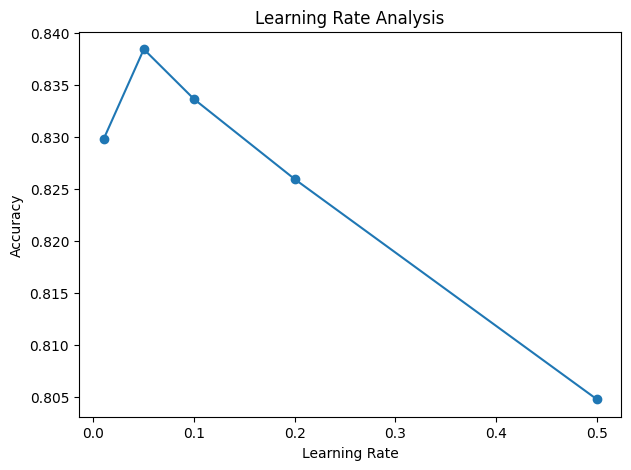

In [11]:
learning_rates = [0.01,0.05,0.1,0.2,0.5]
accuracy = []

for lr in learning_rates:

    model = GradientBoostingClassifier(
        learning_rate=lr,
        n_estimators=200,
        random_state=42
    )

    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    accuracy.append(accuracy_score(y_test,pred))

plt.figure(figsize=(7,5))

plt.plot(learning_rates,accuracy,marker="o")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("Learning Rate Analysis")
plt.show()

## Number of Estimators Analysis

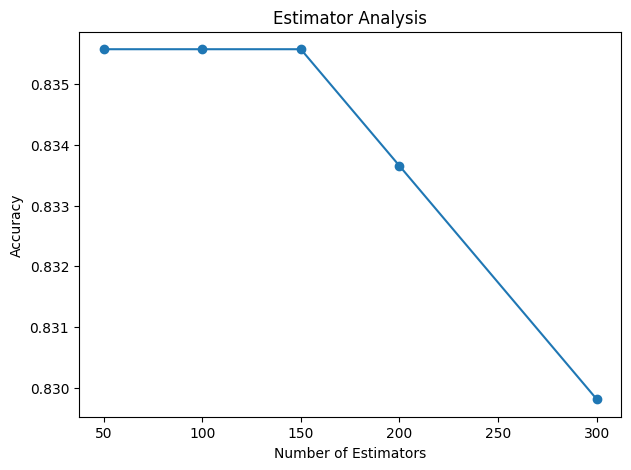

In [12]:
estimators = [50,100,150,200,300]

accuracy = []

for n in estimators:

    model = GradientBoostingClassifier(
        n_estimators=n,
        random_state=42
    )

    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    accuracy.append(accuracy_score(y_test,pred))

plt.figure(figsize=(7,5))

plt.plot(estimators,accuracy,marker="o")
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("Estimator Analysis")
plt.show()

## Classification Comparison

In [13]:
classification_results = pd.DataFrame({

    "Model":["Decision Tree","Gradient Boosting"],
    "Accuracy":[dt_accuracy,gb_accuracy],
    "Precision":[dt_precision,gb_precision],
    "Recall":[dt_recall,gb_recall],
    "F1":[dt_f1,gb_f1],
    "ROC AUC":[dt_auc,gb_auc]
})

classification_results

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Decision Tree,0.768269,0.679245,0.732824,0.705018,0.761312
1,Gradient Boosting,0.833654,0.787958,0.765903,0.776774,0.903760


# REGRESSION

## Feature & Target

In [15]:
X = df.drop(["final_score"],axis=1)

y = df["final_score"]

## Train Test Split

In [16]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Decision Tree Regressor

In [17]:
dtr = DecisionTreeRegressor(random_state=42)

dtr.fit(X_train,y_train)

dt_pred = dtr.predict(X_test)

## Evaluation

In [18]:
dt_mae = mean_absolute_error(y_test,dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test,dt_pred))
dt_r2 = r2_score(y_test,dt_pred)
print(dt_mae,dt_rmse,dt_r2)

9.234615384615385 11.773122094251542 0.2581528173374218


## Gradient Boosting Regressor

In [19]:
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train,y_train)
gb_pred = gbr.predict(X_test)

## Evaluation

In [20]:
gb_mae = mean_absolute_error(y_test,gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test,gb_pred))
gb_r2 = r2_score(y_test,gb_pred)

print("MAE :",gb_mae)
print("RMSE :",gb_rmse)
print("R2 :",gb_r2)

MAE : 6.675865167871985
RMSE : 8.333093312230009
R2 : 0.628341862812194


## Actual vs Predicted

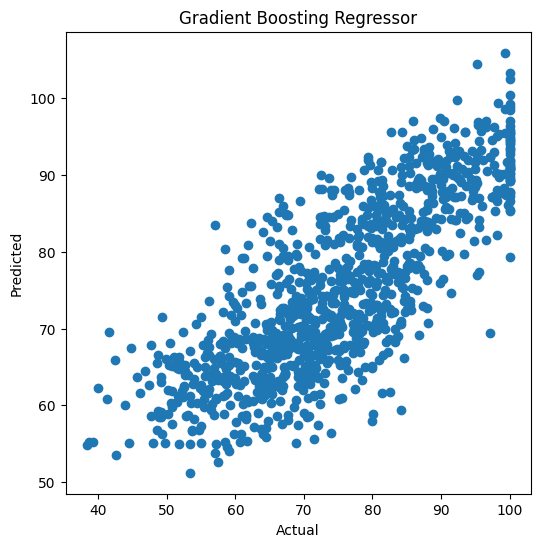

In [21]:
plt.figure(figsize=(6,6))

plt.scatter(y_test,gb_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Gradient Boosting Regressor")
plt.show()

## Learning Rate Analysis (Regression)

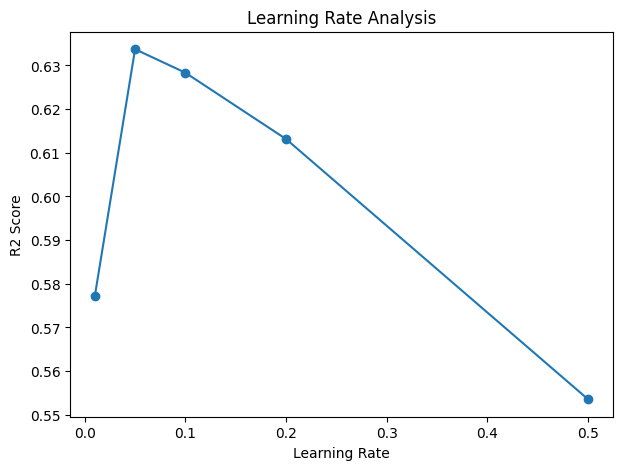

In [22]:
learning_rates = [0.01,0.05,0.1,0.2,0.5]
r2_scores = []

for lr in learning_rates:

    model = GradientBoostingRegressor(
        learning_rate=lr,
        n_estimators=200,
        random_state=42
    )

    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    r2_scores.append(r2_score(y_test,pred))

plt.figure(figsize=(7,5))

plt.plot(learning_rates,r2_scores,marker="o")
plt.xlabel("Learning Rate")
plt.ylabel("R2 Score")
plt.title("Learning Rate Analysis")
plt.show()

## Number of Estimators Analysis

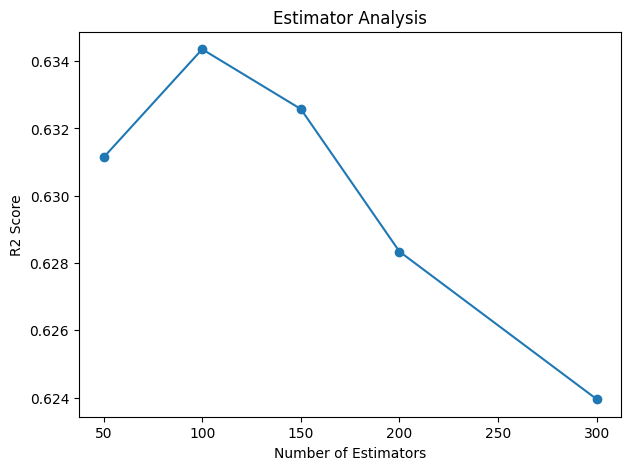

In [23]:
estimators = [50,100,150,200,300]

r2_scores = []

for n in estimators:

    model = GradientBoostingRegressor(
        n_estimators=n,
        random_state=42
    )

    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    r2_scores.append(r2_score(y_test,pred))

plt.figure(figsize=(7,5))

plt.plot(estimators,r2_scores,marker="o")
plt.xlabel("Number of Estimators")
plt.ylabel("R2 Score")
plt.title("Estimator Analysis")
plt.show()

## Regression Comparison

In [24]:
regression_results = pd.DataFrame({

    "Model":["Decision Tree","Gradient Boosting"],
    "MAE":[dt_mae,gb_mae],
    "RMSE":[dt_rmse,gb_rmse],
    "R2 Score":[dt_r2,gb_r2]
})

regression_results

,Model,MAE,RMSE,R2 Score
0,Decision Tree,9.234615,11.773122,0.258153
1,Gradient Boosting,6.675865,8.333093,0.628342


## Final Comparison

In [25]:
print("Classification Results")
print(classification_results)

print("\nRegression Results")
print(regression_results)

Classification Results
               Model  Accuracy  Precision    Recall        F1   ROC AUC
0      Decision Tree  0.768269   0.679245  0.732824  0.705018  0.761312
1  Gradient Boosting  0.833654   0.787958  0.765903  0.776774  0.903760

Regression Results
               Model       MAE       RMSE  R2 Score
0      Decision Tree  9.234615  11.773122  0.258153
1  Gradient Boosting  6.675865   8.333093  0.628342


# Conclusion

## Gradient Boosting Classifier:
The Gradient Boosting Classifier sequentially builds decision trees, where each tree corrects the errors of the previous one. Compared to a single Decision Tree, it generally achieves higher Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

## Gradient Boosting Regressor:
The Gradient Boosting Regressor improves prediction accuracy by minimizing residual errors iteratively. It typically achieves a lower MAE and RMSE and a higher R² score than a single Decision Tree Regressor.

## Learning Rate and Number of Estimators Analysis:

* A very low learning rate may require more estimators and increase training time.
* A high learning rate can converge faster but may overfit.
* Increasing the number of estimators usually improves performance up to a point, after which gains become small or overfitting may occur.
* Selecting an appropriate combination of learning rate and number of estimators provides the best balance between accuracy and generalization.